In [62]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.signal import butter, cheby1, cheby2, ellip, freqz

In [89]:
# Filterparameter

# Ordnung
order = 2
order_b = 1

# Abtastfrequenz für Audioanwendungen
fs = 44100

# Grenzfrequenz für Tief- und Hochpass
fc = 1000
# Normalisiert Grenzfrequenz
wn = fc / (fs/2)

#Untere und obere Grenzen für Bandpass und Bandsperre
low = 500
high = 2000
# Normalisierte untere und obere Grenzfrequenz
wn_b = [low/(fs/2), high/(fs/2)]

# Ripple und Dämpung des Durchlass- und Sperrbereichs
rp = 0.5
rs = 80

In [76]:
# Butter Tiefpass Filterentwurf
b_lp_bw, a_lp_bw = butter(N=order, Wn=wn, btype='low', analog=False)
z_lp_bw, p_lp_bw, k_lp_bw = butter(N=order, Wn=wn, btype='low', analog=False, output='zpk')
sos_lp_bw = butter(N=order, Wn=wn, btype='low', analog=False, output='sos')

# Frequenzgang berechnen
w_lp_bw, h_lp_bw = freqz(b_lp_bw, a_lp_bw, worN=1024, fs=fs)

# Koeffizienten
print('Butterworth-Tiefpass')
print('b Koeffizienten:', b_lp_bw)
print('a Koeffizienten:', a_lp_bw)
print('SOS-Matrix:')
for i, section in enumerate(sos_lp_bw):
    print(f"Section {i + 1}: {section}")

Butterworth-Tiefpass
b Koeffizienten: [0.004604 0.009208 0.004604]
a Koeffizienten: [ 1.         -1.79909641  0.8175124 ]
SOS-Matrix:
Section 1: [ 0.004604    0.009208    0.004604    1.         -1.79909641  0.8175124 ]


In [77]:
# Cheby1 Tiefpass Filterentwurf
b_lp_c1, a_lp_c1 = cheby1(N=order, rp=rp, Wn=wn, btype='low', analog=False)
z_lp_c1, p_lp_c1, k_lp_c1 = cheby1(N=order, rp=rp, Wn=wn, btype='low', analog=False, output='zpk')
sos_lp_c1 = cheby1(N=order, rp=rp, Wn=wn, btype='low', analog=False, output='sos')

# Frequenzgang berechnen
w_lp_c1, h_lp_c1 = freqz(b_lp_c1, a_lp_c1, worN=1024, fs=fs)

# Koeffizienten
print('Chebyshev1-Tiefpass')
print('b Koeffizienten:', b_lp_c1)
print('a Koeffizienten:', a_lp_c1)
print('SOS-Matrix:')
for i, section in enumerate(sos_lp_c1):
    print(f"Section {i + 1}: {section}")

Chebychev1-Tiefpass
b Koeffizienten: [0.00656966 0.01313931 0.00656966]
a Koeffizienten: [ 1.         -1.78877508  0.81661081]
SOS-Matrix:
Section 1: [ 0.00656966  0.01313931  0.00656966  1.         -1.78877508  0.81661081]


In [78]:
# Cheby2 Tiefpass Filterentwurf
b_lp_c2, a_lp_c2 = cheby2(N=order, rs=rs, Wn=wn, btype='low', analog=False)
z_lp_c2, p_lp_c2, k_lp_c2 = cheby2(N=order, rs=rs, Wn=wn, btype='low', analog=False, output='zpk')
sos_lp_c2 = cheby2(N=order, rs=rs, Wn=wn, btype='low', analog=False, output='sos')

# Frequenzgang berechnen
w_lp_c2, h_lp_c2 = freqz(b_lp_c2, a_lp_c2, worN=1024, fs=fs)

# Koeffizienten
print('Chebyshev2-Tiefpass')
print('b Koeffizienten:', b_lp_c2)
print('a Koeffizienten:', a_lp_c2)
print('SOS-Matrix:')
for i, section in enumerate(sos_lp_c2):
    print(f"Section {i + 1}: {section}")

Chebychev2-Tiefpass
b Koeffizienten: [ 0.00010087 -0.00019768  0.00010087]
a Koeffizienten: [ 1.         -1.9971458   0.99714987]
SOS-Matrix:
Section 1: [ 1.00874352e-04 -1.97680863e-04  1.00874352e-04  1.00000000e+00
 -1.99714580e+00  9.97149866e-01]


In [79]:
# Ellip Tiefpass Filterentwurf
b_lp_ep, a_lp_ep = ellip(N=order, rp=rp, rs=rs, Wn=wn, btype='low', analog=False)
z_lp_ep, p_lp_ep, k_lp_ep = ellip(N=order, rp=rp, rs=rs, Wn=wn, btype='low', analog=False, output='zpk')
sos_lp_ep = ellip(N=order, rp=rp, rs=rs, Wn=wn, btype='low', analog=False, output='sos')

# Frequenzgang berechnen
w_lp_ep, h_lp_ep = freqz(b_lp_ep, a_lp_ep, worN=1024, fs=fs)

# Koeffizienten
print('Elliptischer Tiefpass')
print('b Koeffizienten:', b_lp_ep)
print('a Koeffizienten:', a_lp_ep)
print('SOS-Matrix:')
for i, section in enumerate(sos_lp_ep):
    print(f"Section {i + 1}: {section}")

Elliptischer-Tiefpass
b Koeffizienten: [0.00666005 0.01295956 0.00666005]
a Koeffizienten: [ 1.         -1.78878285  0.81661968]
SOS-Matrix:
Section 1: [ 0.00666005  0.01295956  0.00666005  1.         -1.78878285  0.81661968]


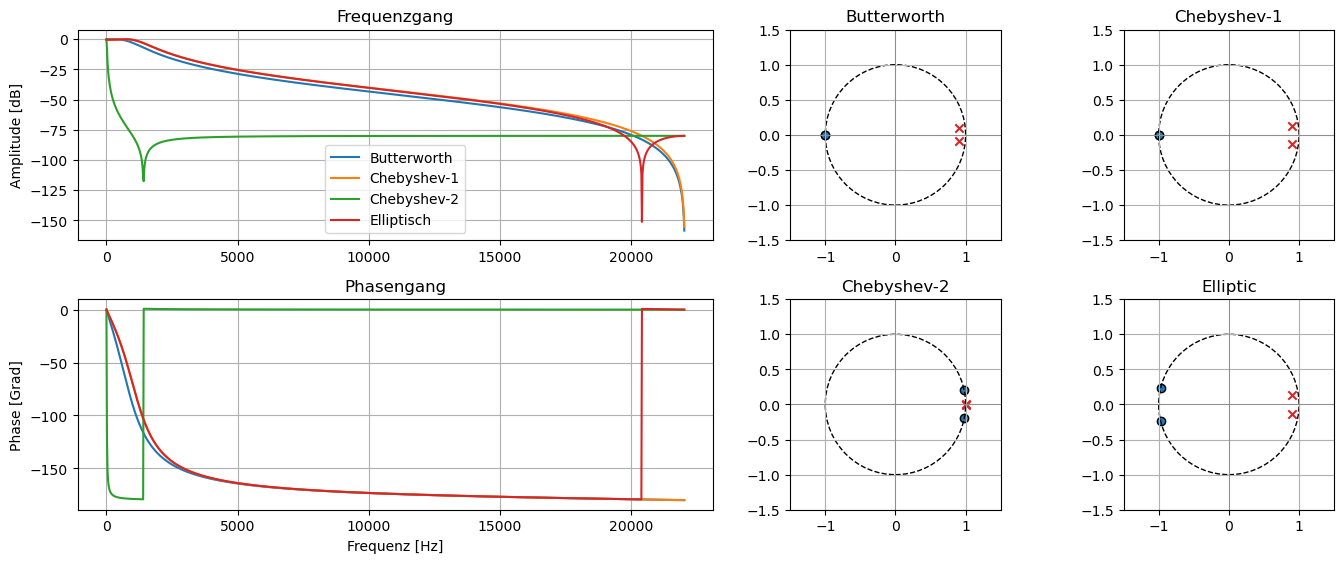

In [93]:
# Plot: Tiefpassvergleich
fig_lp = plt.figure(figsize=(14, 8))
gs_lp = fig_lp.add_gridspec(3, 4)

ax_mag_lp = fig_lp.add_subplot(gs_lp[0, :2])
ax_phase_lp = fig_lp.add_subplot(gs_lp[1, :2], sharex=ax_mag_lp)

# Subplots für Pol-/Nullstellen (2x2 rechts oben)
ax_pz1_lp = fig_lp.add_subplot(gs_lp[0, 2])
ax_pz2_lp = fig_lp.add_subplot(gs_lp[0, 3])
ax_pz3_lp = fig_lp.add_subplot(gs_lp[1, 2])
ax_pz4_lp = fig_lp.add_subplot(gs_lp[1, 3])

ax_mag_lp.plot(w_lp_bw, 20 * np.log10(np.maximum(np.abs(h_lp_bw),1e-10)), label='Butterworth')
ax_phase_lp.plot(w_lp_bw, np.unwrap(np.angle(h_lp_bw))*(180/np.pi), label = 'Butterworth')
ax_pz1_lp.scatter(np.real(z_lp_bw), np.imag(z_lp_bw), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz1_lp.scatter(np.real(p_lp_bw), np.imag(p_lp_bw), marker='x', color='tab:red')
ax_pz1_lp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz1_lp.set_title("Butterworth")

ax_mag_lp.plot(w_lp_c1, 20 * np.log10(np.maximum(np.abs(h_lp_c1),1e-10)), label='Chebyshev-1')
ax_phase_lp.plot(w_lp_c1, np.unwrap(np.angle(h_lp_c1))*(180/np.pi), label = 'Chebyshev-1')
ax_pz2_lp.scatter(np.real(z_lp_c1), np.imag(z_lp_c1), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz2_lp.scatter(np.real(p_lp_c1), np.imag(p_lp_c1), marker='x', color='tab:red')
ax_pz2_lp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz2_lp.set_title("Chebyshev-1")

ax_mag_lp.plot(w_lp_c2, 20 * np.log10(np.maximum(np.abs(h_lp_c2),1e-10)), label='Chebyshev-2')
ax_phase_lp.plot(w_lp_c2, np.unwrap(np.angle(h_lp_c2))*(180/np.pi), label = 'Chebyshev-2')
ax_pz3_lp.scatter(np.real(z_lp_c2), np.imag(z_lp_c2), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz3_lp.scatter(np.real(p_lp_c2), np.imag(p_lp_c2), marker='x', color='tab:red')
ax_pz3_lp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz3_lp.set_title("Chebyshev-2")

ax_mag_lp.plot(w_lp_ep, 20 * np.log10(np.maximum(np.abs(h_lp_ep),1e-10)), label='Elliptisch')
ax_phase_lp.plot(w_lp_ep, np.unwrap(np.angle(h_lp_ep))*(180/np.pi), label = 'Elliptisch')
ax_pz4_lp.scatter(np.real(z_lp_ep), np.imag(z_lp_ep), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz4_lp.scatter(np.real(p_lp_ep), np.imag(p_lp_ep), marker='x', color='tab:red')
ax_pz4_lp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz4_lp.set_title("Elliptisch")

# Einstellungen für alle Subplots
for ax_lp in [ax_pz1_lp, ax_pz2_lp, ax_pz3_lp, ax_pz4_lp]:
    ax_lp.axhline(0, color='gray', lw=0.5)
    ax_lp.axvline(0, color='gray', lw=0.5)
    ax_lp.set_xlim([-1.5, 1.5])
    ax_lp.set_ylim([-1.5, 1.5])
    ax_lp.set_aspect('equal')
    ax_lp.grid(True)

# Frequenz- und Phasengang
ax_mag_lp.set_title("Frequenzgang")
ax_mag_lp.set_ylabel("Amplitude [dB]")
ax_mag_lp.grid(True)
ax_mag_lp.legend()

ax_phase_lp.set_title("Phasengang")
ax_phase_lp.set_ylabel("Phase [Grad]")
ax_phase_lp.set_xlabel("Frequenz [Hz]")
ax_phase_lp.grid(True)

plt.tight_layout()
plt.show()

In [81]:
# Butter Hochpass Filterentwurf
b_hp_bw, a_hp_bw = butter(N=order, Wn=wn, btype='high', analog=False)
z_hp_bw, p_hp_bw, k_hp_bw = butter(N=order, Wn=wn, btype='high', analog=False, output='zpk')
sos_hp_bw = butter(N=order, Wn=wn, btype='high', analog=False, output='sos')

# Frequenzgang berechnen
w_hp_bw, h_hp_bw = freqz(b_hp_bw, a_hp_bw, worN=1024, fs=fs)

# Koeffizienten
print('Butterworth-Hochpass')
print('b Koeffizienten:', b_hp_bw)
print('a Koeffizienten:', a_hp_bw)
print('SOS-Matrix:')
for i, section in enumerate(sos_hp_bw):
    print(f"Section {i + 1}: {section}")

Butterworth-Tiefpass
b Koeffizienten: [ 0.9041522  -1.80830441  0.9041522 ]
a Koeffizienten: [ 1.         -1.79909641  0.8175124 ]
SOS-Matrix:
Section 1: [ 0.9041522  -1.80830441  0.9041522   1.         -1.79909641  0.8175124 ]


In [82]:
# Cheby1 Hochpass Filterentwurf
b_hp_c1, a_hp_c1 = cheby1(N=order, rp=rp, Wn=wn, btype='high', analog=False)
z_hp_c1, p_hp_c1, k_hp_c1 = cheby1(N=order, rp=rp, Wn=wn, btype='high', analog=False, output='zpk')
sos_hp_c1 = cheby1(N=order, rp=rp, Wn=wn, btype='high', analog=False, output='sos')

# Frequenzgang berechnen
w_hp_c1, h_hp_c1 = freqz(b_hp_c1, a_hp_c1, worN=1024, fs=fs)

# Koeffizienten
print('Chebyshev1-Hochpass')
print('b Koeffizienten:', b_hp_c1)
print('a Koeffizienten:', a_hp_c1)
print('SOS-Matrix:')
for i, section in enumerate(sos_hp_c1):
    print(f"Section {i + 1}: {section}")

Chebychev1-Tiefpass
b Koeffizienten: [ 0.88192557 -1.76385114  0.88192557]
a Koeffizienten: [ 1.         -1.86209112  0.87464067]
SOS-Matrix:
Section 1: [ 0.88192557 -1.76385114  0.88192557  1.         -1.86209112  0.87464067]


In [83]:
# Cheby2 Hochpass Filterentwurf
b_hp_c2, a_hp_c2 = cheby2(N=order, rs=rs, Wn=wn, btype='high', analog=False)
z_hp_c2, p_hp_c2, k_hp_c2 = cheby2(N=order, rs=rs, Wn=wn, btype='high', analog=False, output='zpk')
sos_hp_c2 = cheby2(N=order, rs=rs, Wn=wn, btype='high', analog=False, output='sos')

# Frequenzgang berechnen
w_hp_c2, h_hp_c2 = freqz(b_hp_c2, a_hp_c2, worN=1024, fs=fs)

# Koeffizienten
print('Chebyshev2-Hochpass')
print('b Koeffizienten:', b_hp_c2)
print('a Koeffizienten:', a_hp_c2)
print('SOS-Matrix:')
for i, section in enumerate(sos_hp_c2):
    print(f"Section {i + 1}: {section}")

Chebychev2-Tiefpass
b Koeffizienten: [ 0.02984139 -0.05937965  0.02984139]
a Koeffizienten: [1.         1.45615188 0.57521431]
SOS-Matrix:
Section 1: [ 0.02984139 -0.05937965  0.02984139  1.          1.45615188  0.57521431]


In [84]:
# Ellip Hochpass Filterentwurf
b_hp_ep, a_hp_ep = ellip(N=order, rp=rp, rs=rs, Wn=wn, btype='high', analog=False)
z_hp_ep, p_hp_ep, k_hp_ep = ellip(N=order, rp=rp, rs=rs, Wn=wn, btype='high', analog=False, output='zpk')
sos_hp_ep = ellip(N=order, rp=rp, rs=rs, Wn=wn, btype='high', analog=False, output='sos')

# Frequenzgang berechnen
w_hp_ep, h_hp_ep = freqz(b_hp_ep, a_hp_ep, worN=1024, fs=fs)

# Koeffizienten
print('Elliptischer Hochpass')
print('b Koeffizienten:', b_hp_ep)
print('a Koeffizienten:', a_hp_ep)
print('SOS-Matrix:')
for i, section in enumerate(sos_hp_ep):
    print(f"Section {i + 1}: {section}")

Elliptischer-Tiefpass
b Koeffizienten: [ 0.88193084 -1.76386043  0.88193084]
a Koeffizienten: [ 1.         -1.8621018   0.87465099]
SOS-Matrix:
Section 1: [ 0.88193084 -1.76386043  0.88193084  1.         -1.8621018   0.87465099]


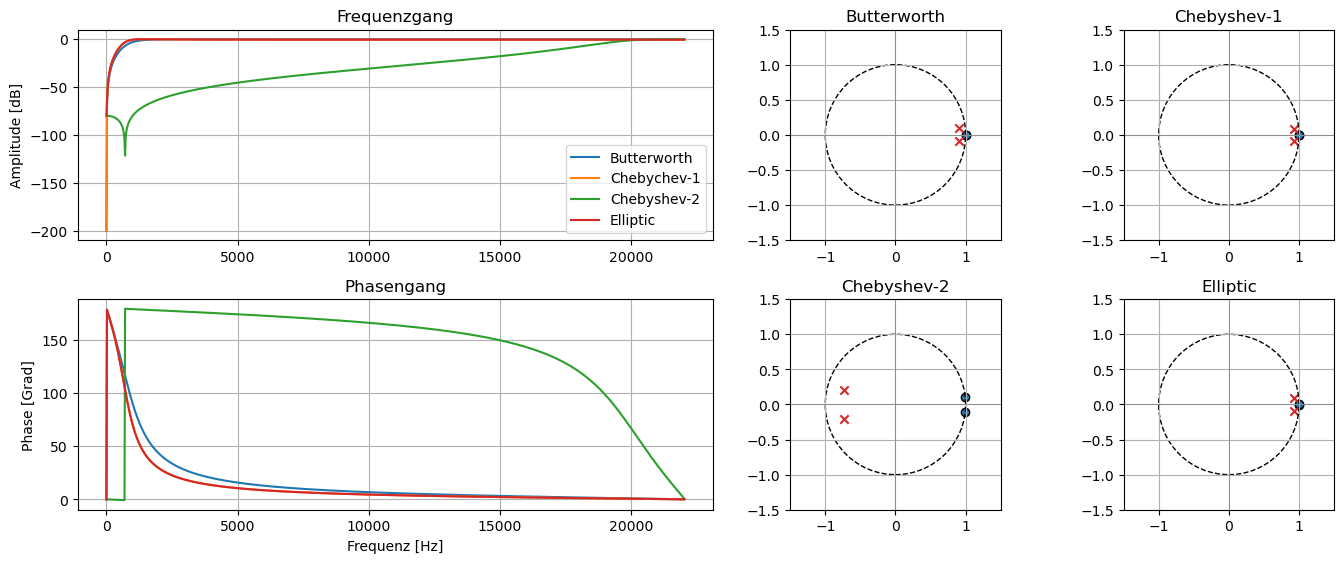

In [85]:
# Plot: Hochpassvergleich
fig_hp = plt.figure(figsize=(14, 8))
gs_hp = fig_hp.add_gridspec(3, 4)

ax_mag_hp = fig_hp.add_subplot(gs_hp[0, :2])
ax_phase_hp = fig_hp.add_subplot(gs_hp[1, :2], sharex=ax_mag_hp)

# Subplots für Pol-/Nullstellen (2x2 rechts oben)
ax_pz1_hp = fig_hp.add_subplot(gs_hp[0, 2])
ax_pz2_hp = fig_hp.add_subplot(gs_hp[0, 3])
ax_pz3_hp = fig_hp.add_subplot(gs_hp[1, 2])
ax_pz4_hp = fig_hp.add_subplot(gs_hp[1, 3])

ax_mag_hp.plot(w_hp_bw, 20 * np.log10(np.maximum(np.abs(h_hp_bw),1e-10)), label='Butterworth')
ax_phase_hp.plot(w_hp_bw, np.unwrap(np.angle(h_hp_bw))*(180/np.pi), label = 'Butterworth')
ax_pz1_hp.scatter(np.real(z_hp_bw), np.imag(z_hp_bw), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz1_hp.scatter(np.real(p_hp_bw), np.imag(p_hp_bw), marker='x', color='tab:red')
ax_pz1_hp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz1_hp.set_title("Butterworth")

ax_mag_hp.plot(w_hp_c1, 20 * np.log10(np.maximum(np.abs(h_hp_c1),1e-10)), label='Chebyshev-1')
ax_phase_hp.plot(w_hp_c1, np.unwrap(np.angle(h_hp_c1))*(180/np.pi), label = 'Chebyshev-1')
ax_pz2_hp.scatter(np.real(z_hp_c1), np.imag(z_hp_c1), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz2_hp.scatter(np.real(p_hp_c1), np.imag(p_hp_c1), marker='x', color='tab:red')
ax_pz2_hp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz2_hp.set_title("Chebyshev-1")

ax_mag_hp.plot(w_hp_c2, 20 * np.log10(np.maximum(np.abs(h_hp_c2),1e-10)), label='Chebyshev-2')
ax_phase_hp.plot(w_hp_c2, np.unwrap(np.angle(h_hp_c2))*(180/np.pi), label = 'Chebyshev-2')
ax_pz3_hp.scatter(np.real(z_hp_c2), np.imag(z_hp_c2), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz3_hp.scatter(np.real(p_hp_c2), np.imag(p_hp_c2), marker='x', color='tab:red')
ax_pz3_hp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz3_hp.set_title("Chebyshev-2")

ax_mag_hp.plot(w_hp_ep, 20 * np.log10(np.maximum(np.abs(h_hp_ep),1e-10)), label='Elliptisch')
ax_phase_hp.plot(w_hp_ep, np.unwrap(np.angle(h_hp_ep))*(180/np.pi), label = 'Elliptisch')
ax_pz4_hp.scatter(np.real(z_hp_ep), np.imag(z_hp_ep), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz4_hp.scatter(np.real(p_hp_ep), np.imag(p_hp_ep), marker='x', color='tab:red')
ax_pz4_hp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz4_hp.set_title("Elliptisch")

# Einstellungen für alle Subplots
for ax_hp in [ax_pz1_hp, ax_pz2_hp, ax_pz3_hp, ax_pz4_hp]:
    ax_hp.axhline(0, color='gray', lw=0.5)
    ax_hp.axvline(0, color='gray', lw=0.5)
    ax_hp.set_xlim([-1.5, 1.5])
    ax_hp.set_ylim([-1.5, 1.5])
    ax_hp.set_aspect('equal')
    ax_hp.grid(True)

# Frequenz- und Phasengang
ax_mag_hp.set_title("Frequenzgang")
ax_mag_hp.set_ylabel("Amplitude [dB]")
ax_mag_hp.grid(True)
ax_mag_hp.legend()

ax_phase_hp.set_title("Phasengang")
ax_phase_hp.set_ylabel("Phase [Grad]")
ax_phase_hp.set_xlabel("Frequenz [Hz]")
ax_phase_hp.grid(True)

plt.tight_layout()
plt.show()

In [92]:
# Butter Bandpass Filterentwurf
b_bp_bw, a_bp_bw = butter(N=order_b, Wn=wn_b, btype='bandpass', analog=False)
z_bp_bw, p_bp_bw, k_bp_bw = butter(N=order_b, Wn=wn_b, btype='bandpass', analog=False, output='zpk')
sos_bp_bw = butter(N=order_b, Wn=wn_b, btype='bandpass', analog=False, output='sos')

# Frequenzgang berechnen
w_bp_bw, h_bp_bw = freqz(b_bp_bw, a_bp_bw, worN=1024, fs=fs)

# Koeffizienten
print('Butterworth-Bandpass')
print('b Koeffizienten:', b_bp_bw)
print('a Koeffizienten:', a_bp_bw)
print('SOS-Matrix:')
for i, section in enumerate(sos_bp_bw):
    print(f"Section {i + 1}: {section}")

Butterworth-Tiefpass
b Koeffizienten: [ 0.09687421  0.         -0.09687421]
a Koeffizienten: [ 1.         -1.78787973  0.80625157]
SOS-Matrix:
Section 1: [ 0.09687421  0.         -0.09687421  1.         -1.78787973  0.80625157]


In [94]:
# Cheby1 Bandpass Filterentwurf
b_bp_c1, a_bp_c1 = cheby1(N=order_b, rp=rp, Wn=wn_b, btype='bandpass', analog=False)
z_bp_c1, p_bp_c1, k_bp_c1 = cheby1(N=order_b, rp=rp, Wn=wn_b, btype='bandpass', analog=False, output='zpk')
sos_bp_c1 = cheby1(N=order_b, rp=rp, Wn=wn_b, btype='bandpass', analog=False, output='sos')

# Frequenzgang berechnen
w_bp_c1, h_bp_c1 = freqz(b_bp_c1, a_bp_c1, worN=1024, fs=fs)

# Koeffizienten
print('Chebychev1-Bandpass')
print('b Koeffizienten:', b_bp_c1)
print('a Koeffizienten:', a_bp_c1)
print('SOS-Matrix:')
for i, section in enumerate(sos_bp_c1):
    print(f"Section {i + 1}: {section}")

Chebychev1-Tiefpass
b Koeffizienten: [ 0.23493409  0.         -0.23493409]
a Koeffizienten: [ 1.         -1.51456846  0.53013182]
SOS-Matrix:
Section 1: [ 0.23493409  0.         -0.23493409  1.         -1.51456846  0.53013182]


In [97]:
# Cheby2 Bandpass Filterentwurf
b_bp_c2, a_bp_c2 = cheby2(N=order_b, rs=rs, Wn=wn_b, btype='bandpass', analog=False)
z_bp_c2, p_bp_c2, k_bp_c2 = cheby2(N=order_b, rs=rs, Wn=wn_b, btype='bandpass', analog=False, output='zpk')
sos_bp_c2 = cheby2(N=order_b, rs=rs, Wn=wn_b, btype='bandpass', analog=False, output='sos')

# Frequenzgang berechnen
w_bp_c2, h_bp_c2 = freqz(b_bp_c2, a_bp_c2, worN=1024, fs=fs)

# Koeffizienten
print('Chebyshev2-Bandpass')
print('b Koeffizienten:', b_bp_c2)
print('a Koeffizienten:', a_bp_c2)
print('SOS-Matrix:')
for i, section in enumerate(sos_bp_c2):
    print(f"Section {i + 1}: {section}")

Chebyshev2-Bandpass
b Koeffizienten: [ 1.07264321e-05  0.00000000e+00 -1.07264321e-05]
a Koeffizienten: [ 1.         -1.97963625  0.99997855]
SOS-Matrix:
Section 1: [ 1.07264321e-05  0.00000000e+00 -1.07264321e-05  1.00000000e+00
 -1.97963625e+00  9.99978547e-01]


In [96]:
# Ellip Bandpass Filterentwurf
b_bp_ep, a_bp_ep = ellip(N=order_b, rp=rp, rs=rs, Wn=wn_b, btype='bandpass', analog=False)
z_bp_ep, p_bp_ep, k_bp_ep = ellip(N=order_b, rp=rp, rs=rs, Wn=wn_b, btype='bandpass', analog=False, output='zpk')
sos_bp_ep = ellip(N=order_b, rp=rp, rs=rs, Wn=wn_b, btype='bandpass', analog=False, output='sos')

# Frequenzgang berechnen
w_bp_ep, h_bp_ep = freqz(b_bp_ep, a_bp_ep, worN=1024, fs=fs)

# Koeffizienten
print('Elliptischer Bandpass')
print('b Koeffizienten:', b_bp_ep)
print('a Koeffizienten:', a_bp_ep)
print('SOS-Matrix:')
for i, section in enumerate(sos_bp_ep):
    print(f"Section {i + 1}: {section}")

Elliptischer Bandpass
b Koeffizienten: [ 0.23493409  0.         -0.23493409]
a Koeffizienten: [ 1.         -1.51456846  0.53013182]
SOS-Matrix:
Section 1: [ 0.23493409  0.         -0.23493409  1.         -1.51456846  0.53013182]


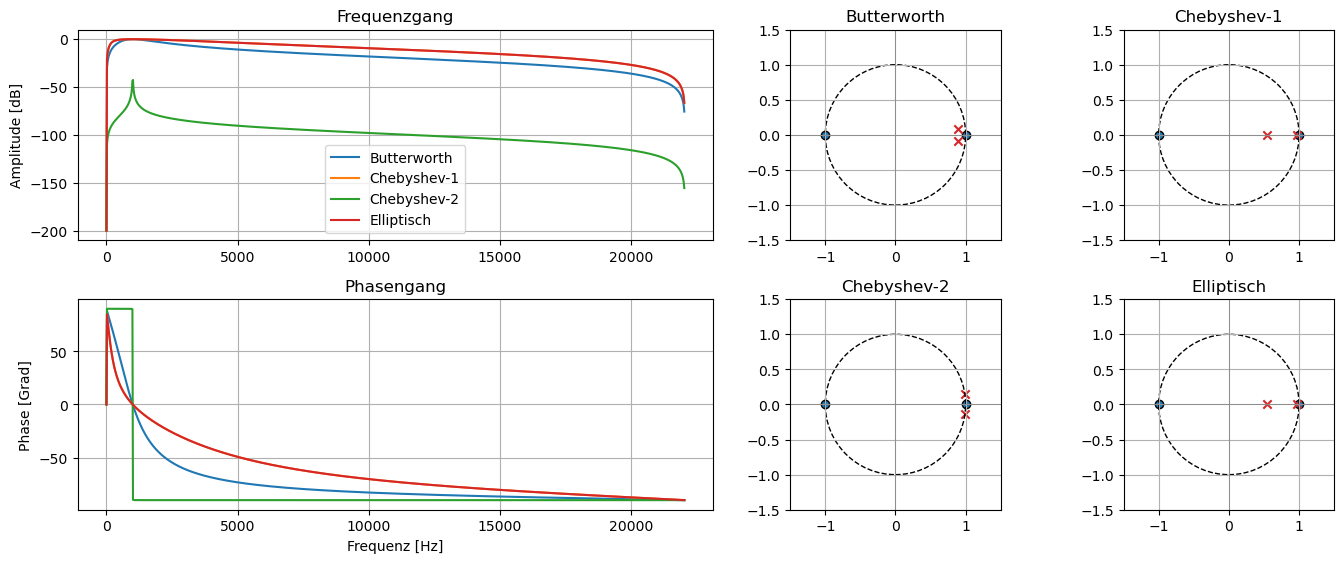

In [99]:
# Plot: Bandpassvergleich
fig_bp = plt.figure(figsize=(14, 8))
gs_bp = fig_bp.add_gridspec(3, 4)

ax_mag_bp = fig_bp.add_subplot(gs_bp[0, :2])
ax_phase_bp = fig_bp.add_subplot(gs_bp[1, :2], sharex=ax_mag_bp)

# Subplots für Pol-/Nullstellen (2x2 rechts oben)
ax_pz1_bp = fig_bp.add_subplot(gs_bp[0, 2])
ax_pz2_bp = fig_bp.add_subplot(gs_bp[0, 3])
ax_pz3_bp = fig_bp.add_subplot(gs_bp[1, 2])
ax_pz4_bp = fig_bp.add_subplot(gs_bp[1, 3])

ax_mag_bp.plot(w_bp_bw, 20 * np.log10(np.maximum(np.abs(h_bp_bw),1e-10)), label='Butterworth')
ax_phase_bp.plot(w_bp_bw, np.unwrap(np.angle(h_bp_bw))*(180/np.pi), label = 'Butterworth')
ax_pz1_bp.scatter(np.real(z_bp_bw), np.imag(z_bp_bw), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz1_bp.scatter(np.real(p_bp_bw), np.imag(p_bp_bw), marker='x', color='tab:red')
ax_pz1_bp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz1_bp.set_title("Butterworth")

ax_mag_bp.plot(w_bp_c1, 20 * np.log10(np.maximum(np.abs(h_bp_c1),1e-10)), label='Chebyshev-1')
ax_phase_bp.plot(w_bp_c1, np.unwrap(np.angle(h_bp_c1))*(180/np.pi), label = 'Chebyshev-1')
ax_pz2_bp.scatter(np.real(z_bp_c1), np.imag(z_bp_c1), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz2_bp.scatter(np.real(p_bp_c1), np.imag(p_bp_c1), marker='x', color='tab:red')
ax_pz2_bp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz2_bp.set_title("Chebyshev-1")

ax_mag_bp.plot(w_bp_c2, 20 * np.log10(np.maximum(np.abs(h_bp_c2),1e-10)), label='Chebyshev-2')
ax_phase_bp.plot(w_bp_c2, np.unwrap(np.angle(h_bp_c2))*(180/np.pi), label = 'Chebyshev-2')
ax_pz3_bp.scatter(np.real(z_bp_c2), np.imag(z_bp_c2), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz3_bp.scatter(np.real(p_bp_c2), np.imag(p_bp_c2), marker='x', color='tab:red')
ax_pz3_bp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz3_bp.set_title("Chebyshev-2")

ax_mag_bp.plot(w_bp_ep, 20 * np.log10(np.maximum(np.abs(h_bp_ep),1e-10)), label='Elliptisch')
ax_phase_bp.plot(w_bp_ep, np.unwrap(np.angle(h_bp_ep))*(180/np.pi), label = 'Elliptisch')
ax_pz4_bp.scatter(np.real(z_bp_ep), np.imag(z_bp_ep), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz4_bp.scatter(np.real(p_bp_ep), np.imag(p_bp_ep), marker='x', color='tab:red')
ax_pz4_bp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz4_bp.set_title("Elliptisch")

# Einstellungen für alle Subplots
for ax_bp in [ax_pz1_bp, ax_pz2_bp, ax_pz3_bp, ax_pz4_bp]:
    ax_bp.axhline(0, color='gray', lw=0.5)
    ax_bp.axvline(0, color='gray', lw=0.5)
    ax_bp.set_xlim([-1.5, 1.5])
    ax_bp.set_ylim([-1.5, 1.5])
    ax_bp.set_aspect('equal')
    ax_bp.grid(True)

# Frequenz- und Phasengang
ax_mag_bp.set_title("Frequenzgang")
ax_mag_bp.set_ylabel("Amplitude [dB]")
ax_mag_bp.grid(True)
ax_mag_bp.legend()

ax_phase_bp.set_title("Phasengang")
ax_phase_bp.set_ylabel("Phase [Grad]")
ax_phase_bp.set_xlabel("Frequenz [Hz]")
ax_phase_bp.grid(True)

plt.tight_layout()
plt.show()

In [101]:
# Butter Bandstop Filterentwurf
b_bs_bw, a_bs_bw = butter(N=order_b, Wn=wn_b, btype='bandstop', analog=False)
z_bs_bw, p_bs_bw, k_bs_bw = butter(N=order_b, Wn=wn_b, btype='bandstop', analog=False, output='zpk')
sos_bs_bw = butter(N=order_b, Wn=wn_b, btype='bandstop', analog=False, output='sos')

# Frequenzgang berechnen
w_bs_bw, h_bs_bw = freqz(b_bs_bw, a_bs_bw, worN=1024, fs=fs)

# Koeffizienten
print('Butterworth-Bandstop')
print('b Koeffizienten:', b_bs_bw)
print('a Koeffizienten:', a_bs_bw)
print('SOS-Matrix:')
for i, section in enumerate(sos_bs_bw):
    print(f"Section {i + 1}: {section}")

Butterworth-Bandstop
b Koeffizienten: [ 0.90312579 -1.78787973  0.90312579]
a Koeffizienten: [ 1.         -1.78787973  0.80625157]
SOS-Matrix:
Section 1: [ 0.90312579 -1.78787973  0.90312579  1.         -1.78787973  0.80625157]


In [102]:
# Cheby1 Bandstop Filterentwurf
b_bs_c1, a_bs_c1 = cheby1(N=order_b, rp=rp, Wn=wn_b, btype='bandstop', analog=False)
z_bs_c1, p_bs_c1, k_bs_c1 = cheby1(N=order_b, rp=rp, Wn=wn_b, btype='bandstop', analog=False, output='zpk')
sos_bs_c1 = cheby1(N=order_b, rp=rp, Wn=wn_b, btype='bandstop', analog=False, output='sos')

# Frequenzgang berechnen
w_bs_c1, h_bs_c1 = freqz(b_bs_c1, a_bs_c1, worN=1024, fs=fs)

# Koeffizienten
print('Chebychev1-Bandstop')
print('b Koeffizienten:', b_bs_c1)
print('a Koeffizienten:', a_bs_c1)
print('SOS-Matrix:')
for i, section in enumerate(sos_bs_c1):
    print(f"Section {i + 1}: {section}")

Chebychev1-Bandstop
b Koeffizienten: [ 0.96388417 -1.90816052  0.96388417]
a Koeffizienten: [ 1.         -1.90816052  0.92776835]
SOS-Matrix:
Section 1: [ 0.96388417 -1.90816052  0.96388417  1.         -1.90816052  0.92776835]


In [103]:
# Cheby2 Bandstop Filterentwurf
b_bs_c2, a_bs_c2 = cheby2(N=order_b, rs=rs, Wn=wn_b, btype='bandstop', analog=False)
z_bs_c2, p_bs_c2, k_bs_c2 = cheby2(N=order_b, rs=rs, Wn=wn_b, btype='bandstop', analog=False, output='zpk')
sos_bs_c2 = cheby2(N=order_b, rs=rs, Wn=wn_b, btype='bandstop', analog=False, output='sos')

# Frequenzgang berechnen
w_bs_c2, h_bs_c2 = freqz(b_bs_c2, a_bs_c2, worN=1024, fs=fs)

# Koeffizienten
print('Chebyshev2-Bandstop')
print('b Koeffizienten:', b_bs_c2)
print('a Koeffizienten:', a_bs_c2)
print('SOS-Matrix:')
for i, section in enumerate(sos_bs_c2):
    print(f"Section {i + 1}: {section}")

Chebyshev2-Bandstop
b Koeffizienten: [ 0.0009314  -0.00184385  0.0009314 ]
a Koeffizienten: [ 1.         -0.00184385 -0.9981372 ]
SOS-Matrix:
Section 1: [ 9.31398148e-04 -1.84384932e-03  9.31398148e-04  1.00000000e+00
 -1.84384932e-03 -9.98137204e-01]


In [104]:
# Ellip Bandstop Filterentwurf
b_bs_ep, a_bs_ep = ellip(N=order_b, rp=rp, rs=rs, Wn=wn_b, btype='bandstop', analog=False)
z_bs_ep, p_bs_ep, k_bs_ep = ellip(N=order_b, rp=rp, rs=rs, Wn=wn_b, btype='bandstop', analog=False, output='zpk')
sos_bs_ep = ellip(N=order_b, rp=rp, rs=rs, Wn=wn_b, btype='bandstop', analog=False, output='sos')

# Frequenzgang berechnen
w_bs_ep, h_bs_ep = freqz(b_bs_ep, a_bs_ep, worN=1024, fs=fs)

# Koeffizienten
print('Elliptischer Bandstop')
print('b Koeffizienten:', b_bs_ep)
print('a Koeffizienten:', a_bs_ep)
print('SOS-Matrix:')
for i, section in enumerate(sos_bs_ep):
    print(f"Section {i + 1}: {section}")

Elliptischer Bandstop
b Koeffizienten: [ 0.96388417 -1.90816052  0.96388417]
a Koeffizienten: [ 1.         -1.90816052  0.92776835]
SOS-Matrix:
Section 1: [ 0.96388417 -1.90816052  0.96388417  1.         -1.90816052  0.92776835]


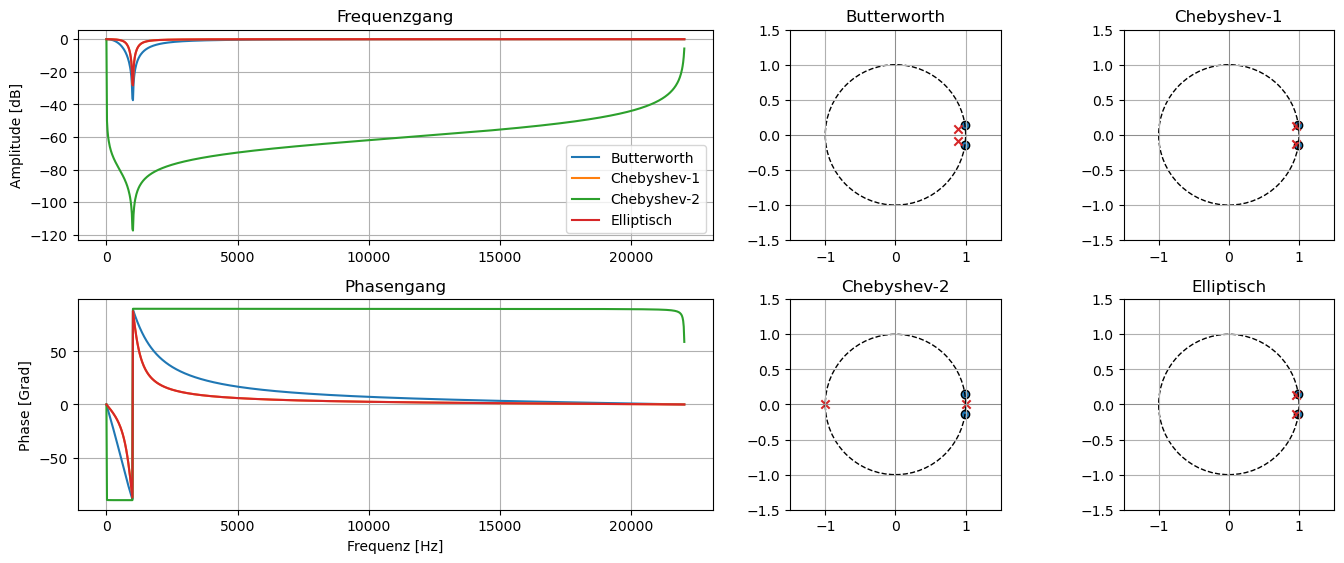

In [105]:
# Plot: Bandstopvergleich
fig_bs = plt.figure(figsize=(14, 8))
gs_bs = fig_bs.add_gridspec(3, 4)

ax_mag_bs = fig_bs.add_subplot(gs_bs[0, :2])
ax_phase_bs = fig_bs.add_subplot(gs_bs[1, :2], sharex=ax_mag_bs)

# Subplots für Pol-/Nullstellen (2x2 rechts oben)
ax_pz1_bs = fig_bs.add_subplot(gs_bs[0, 2])
ax_pz2_bs = fig_bs.add_subplot(gs_bs[0, 3])
ax_pz3_bs = fig_bs.add_subplot(gs_bs[1, 2])
ax_pz4_bs = fig_bs.add_subplot(gs_bs[1, 3])

ax_mag_bs.plot(w_bs_bw, 20 * np.log10(np.maximum(np.abs(h_bs_bw),1e-10)), label='Butterworth')
ax_phase_bs.plot(w_bs_bw, np.unwrap(np.angle(h_bs_bw))*(180/np.pi), label = 'Butterworth')
ax_pz1_bs.scatter(np.real(z_bs_bw), np.imag(z_bs_bw), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz1_bs.scatter(np.real(p_bs_bw), np.imag(p_bs_bw), marker='x', color='tab:red')
ax_pz1_bs.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz1_bs.set_title("Butterworth")

ax_mag_bs.plot(w_bs_c1, 20 * np.log10(np.maximum(np.abs(h_bs_c1),1e-10)), label='Chebyshev-1')
ax_phase_bs.plot(w_bs_c1, np.unwrap(np.angle(h_bs_c1))*(180/np.pi), label = 'Chebyshev-1')
ax_pz2_bs.scatter(np.real(z_bs_c1), np.imag(z_bs_c1), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz2_bs.scatter(np.real(p_bs_c1), np.imag(p_bs_c1), marker='x', color='tab:red')
ax_pz2_bs.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz2_bs.set_title("Chebyshev-1")

ax_mag_bs.plot(w_bs_c2, 20 * np.log10(np.maximum(np.abs(h_bs_c2),1e-10)), label='Chebyshev-2')
ax_phase_bs.plot(w_bs_c2, np.unwrap(np.angle(h_bs_c2))*(180/np.pi), label = 'Chebyshev-2')
ax_pz3_bs.scatter(np.real(z_bs_c2), np.imag(z_bs_c2), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz3_bs.scatter(np.real(p_bs_c2), np.imag(p_bs_c2), marker='x', color='tab:red')
ax_pz3_bs.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz3_bs.set_title("Chebyshev-2")

ax_mag_bs.plot(w_bs_ep, 20 * np.log10(np.maximum(np.abs(h_bs_ep),1e-10)), label='Elliptisch')
ax_phase_bs.plot(w_bs_ep, np.unwrap(np.angle(h_bs_ep))*(180/np.pi), label = 'Elliptisch')
ax_pz4_bs.scatter(np.real(z_bs_ep), np.imag(z_bs_ep), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz4_bs.scatter(np.real(p_bs_ep), np.imag(p_bs_ep), marker='x', color='tab:red')
ax_pz4_bs.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz4_bs.set_title("Elliptisch")

# Einstellungen für alle Subplots
for ax_bs in [ax_pz1_bs, ax_pz2_bs, ax_pz3_bs, ax_pz4_bs]:
    ax_bs.axhline(0, color='gray', lw=0.5)
    ax_bs.axvline(0, color='gray', lw=0.5)
    ax_bs.set_xlim([-1.5, 1.5])
    ax_bs.set_ylim([-1.5, 1.5])
    ax_bs.set_aspect('equal')
    ax_bs.grid(True)

# Frequenz- und Phasengang
ax_mag_bs.set_title("Frequenzgang")
ax_mag_bs.set_ylabel("Amplitude [dB]")
ax_mag_bs.grid(True)
ax_mag_bs.legend()

ax_phase_bs.set_title("Phasengang")
ax_phase_bs.set_ylabel("Phase [Grad]")
ax_phase_bs.set_xlabel("Frequenz [Hz]")
ax_phase_bs.grid(True)

plt.tight_layout()
plt.show()